# Porto and Lisbon Urban Heat Island Exposure and Population Characteristics

This notebook reads the prepared real-data table for **Lisbon** and **Porto** and reproduces the core exposure and representation metrics used throughout this project.

The question is narrow by design:

> Which groups are more or less represented in cells with stronger modelled urban heat island intensity?

The notebook also tackles the more basic question behind the heat itself:

> Do greener cells run cooler? Are built-up centres without parks hotter than well-vegetated areas?

We answer that directly by measuring each cell's park/vegetation cover from OpenStreetMap and relating it to the modelled urban-heat-island intensity.

## Sources and interpretation

This analysis combines three official or near-official inputs:

- the **Eurostat GISCO Census 2021 1 km grid** for total population, children, older residents, employed residents, and people born outside the EU;
- the **Eurostat GISCO Urban Audit `CITIES` polygons** for Lisbon and Porto;
- the **EEA public service exposing the Copernicus/UrbClim urban heat island model**.

Two interpretation points matter before reading the results:

1. The Urban Audit `CITIES` polygons are **not municipality boundaries**, so the city totals here are larger than the municipality-only populations many readers expect.
2. Some coastal or no-data fragments do not return a direct UHI pixel value from the public service. Those fragments were filled with the nearest non-missing value within the same city during the preparation step, and that assumption is documented in `data/SOURCES.md`.


## Method

This notebook works from the prepared table rather than rebuilding the geospatial pipeline inline.

At a high level, the preparation workflow does this:

1. Intersect the Eurostat 1 km grid with the Lisbon and Porto Urban Audit city polygons.
2. Apply area weights when a grid cell is split by a city boundary.
3. Attach one UHI intensity value to each resulting fragment.
4. Mark fragments as exposed when `uhi_intensity_celsius >= 2.0` by default.
5. Compare each group's share in the whole city with its share inside exposed fragments.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import numpy as np
import pandas as pd
from IPython.display import Image, display

from uhi_exposure.io import load_exposure_cells, write_dataframe
from uhi_exposure.green import attach_green_fraction
from uhi_exposure.metrics import (
    compute_city_exposure_summary,
    compute_dose_response,
    compute_double_burden,
    compute_exposure_band_decomposition,
    compute_group_representation,
    compute_group_representation_by_threshold,
    compute_threshold_sensitivity,
    bootstrap_group_representation,
    compute_green_uhi_relationship,
    compute_uhi_by_green_band,
)
from uhi_exposure.plotting import (
    plot_exposed_population_share,
    plot_dose_response,
    plot_exposure_band_decomposition,
    plot_group_share_comparison,
    plot_group_threshold_small_multiples,
    plot_hotspot_map,
    plot_population_uhi_band_comparison,
    plot_population_weighted_uhi_distribution,
    plot_representation_heatmap,
    plot_representation_with_ci,
    plot_green_vs_uhi,
    plot_uhi_by_green_band,
    plot_representation_ratios,
    plot_threshold_sensitivity,
)
from uhi_exposure.spatial import prepared_cells_to_geodataframe


C:\Users\diogo\AppData\Roaming\Python\Python313\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (6.0.0.post1)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


## Configuration

The notebook is configured for the real prepared table by default.

Change the threshold only if you want to test a different exposure definition. Keep in mind that a higher threshold can materially reduce the exposed population share, especially in Lisbon with the current source combination.


In [2]:
USE_DEMO = False
UHI_THRESHOLD_CELSIUS = 2.0
REAL_DATA_PATH = PROJECT_ROOT / "data" / "manual" / "porto_lisbon_cells.csv"
DEMO_DATA_PATH = PROJECT_ROOT / "data" / "demo" / "porto_lisbon_demo_cells.csv"
INPUT_PATH = DEMO_DATA_PATH if USE_DEMO else REAL_DATA_PATH
OUTPUT_DIR = PROJECT_ROOT / "outputs"
PLOT_DIR = PROJECT_ROOT / "plots"
GREEN_CACHE = PROJECT_ROOT / "data" / "raw" / "green_fraction.csv"

print(f"Using input: {INPUT_PATH}")
print(f"UHI threshold: {UHI_THRESHOLD_CELSIUS:.1f} °C")


Using input: C:\Users\diogo\work_code\ds-projects-portfolio\projects\porto_lisbon_uhi_exposure\data\manual\porto_lisbon_cells.csv
UHI threshold: 2.0 °C


## Load the prepared cell-level table

This cell reads the prepared CSV and shows the first rows so you can verify the schema and the expected fractional counts from area weighting.

Expected columns:

```text
city,cell_id,population_total,age_0_14,age_65_plus,employed,born_outside_eu,uhi_intensity_celsius,is_uhi_exposed
```


In [3]:
cells = load_exposure_cells(INPUT_PATH)
cells.head()

,city,cell_id,population_total,age_0_14,age_65_plus,employed,born_outside_eu,uhi_intensity_celsius,is_uhi_exposed
0,Lisbon,CRS3035RES1000mN1929000E2657000,0.000000,0.000000,0.000000,0.000000,0.000000,0.140198,False
1,Lisbon,CRS3035RES1000mN1933000E2674000,0.658670,0.099566,0.107225,0.245087,0.045954,1.645599,False
2,Lisbon,CRS3035RES1000mN1930000E2674000,1.879807,0.244013,0.478989,0.759153,0.126525,1.669006,False
3,Lisbon,CRS3035RES1000mN1929000E2674000,3.050808,0.435830,0.174332,1.220323,0.087166,1.477478,False
4,Lisbon,CRS3035RES1000mN1925000E2668000,29.370680,3.012377,6.150271,14.434308,4.769598,1.265320,False


In [4]:
cells.groupby("city", as_index=False).agg(
    cells=("cell_id", "count"),
    total_population=("population_total", "sum"),
    mean_uhi=("uhi_intensity_celsius", "mean"),
    max_uhi=("uhi_intensity_celsius", "max"),
)

,city,cells,total_population,mean_uhi,max_uhi
0,Lisbon,793,1.850999e+06,0.714196,2.234589
1,Porto,585,9.583587e+05,1.110140,2.300751


## City-level exposure summary

This table answers the first high-level question: how much of each city's population sits above the current UHI threshold?

Read it together with the mean and exposed-area mean. A city can have a modest average UHI level and still have a meaningful hot tail, or vice versa.


In [5]:
city_summary = compute_city_exposure_summary(cells, threshold=UHI_THRESHOLD_CELSIUS)
city_summary

,city,total_population,exposed_population,exposed_population_share,mean_uhi_intensity_celsius,mean_uhi_intensity_exposed_celsius
0,Lisbon,1.850999e+06,19518.178566,0.010545,1.030735,2.121989
1,Porto,9.583587e+05,61532.000000,0.064206,1.507904,2.095122


## UHI distribution and threshold context

Before focusing only on a `2.0 °C` cutoff, it helps to inspect the full distribution. These quantiles show how much warmer Porto is across the upper half of the distribution, not only at the extreme tail.


In [6]:
uhi_distribution = (
    cells.groupby("city")["uhi_intensity_celsius"]
    .quantile([0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0])
    .unstack()
    .rename(
        columns={
            0.0: "min",
            0.1: "p10",
            0.25: "p25",
            0.5: "median",
            0.75: "p75",
            0.9: "p90",
            1.0: "max",
        }
    )
)

uhi_distribution.round(3)

,min,p10,p25,median,p75,p90,max
city,,,,,,,
Lisbon,-1.026,-0.185,0.159,0.710,1.325,1.711,2.235
Porto,-0.550,0.204,0.795,1.222,1.497,1.734,2.301


## Population across UHI bands

The next table shifts the unit from *cells* to *people*. This is more informative because some fragments are almost unpopulated while others contain a large share of each city's residents.


In [7]:
uhi_band_bins = [-np.inf, 0.0, 0.5, 1.0, 1.5, 2.0, np.inf]
uhi_band_labels = ["<0.0", "0.0-0.5", "0.5-1.0", "1.0-1.5", "1.5-2.0", ">=2.0"]

uhi_band_summary = (
    cells.assign(
        uhi_band=pd.cut(
            cells["uhi_intensity_celsius"],
            bins=uhi_band_bins,
            labels=uhi_band_labels,
            right=False,
        )
    )
    .groupby(["city", "uhi_band"], observed=False)["population_total"]
    .sum()
    .rename("population_in_band")
    .reset_index()
)

city_totals = cells.groupby("city")["population_total"].sum().rename("city_total_population")
uhi_band_summary = uhi_band_summary.merge(city_totals, on="city", how="left")
uhi_band_summary["population_share_in_band"] = (
    uhi_band_summary["population_in_band"] / uhi_band_summary["city_total_population"]
)

uhi_band_summary.pivot(index="uhi_band", columns="city", values="population_share_in_band").round(3)

city,Lisbon,Porto
uhi_band,,
<0.0,0.075,0.001
0.0-0.5,0.121,0.017
0.5-1.0,0.204,0.093
1.0-1.5,0.370,0.298
1.5-2.0,0.219,0.527
>=2.0,0.011,0.064


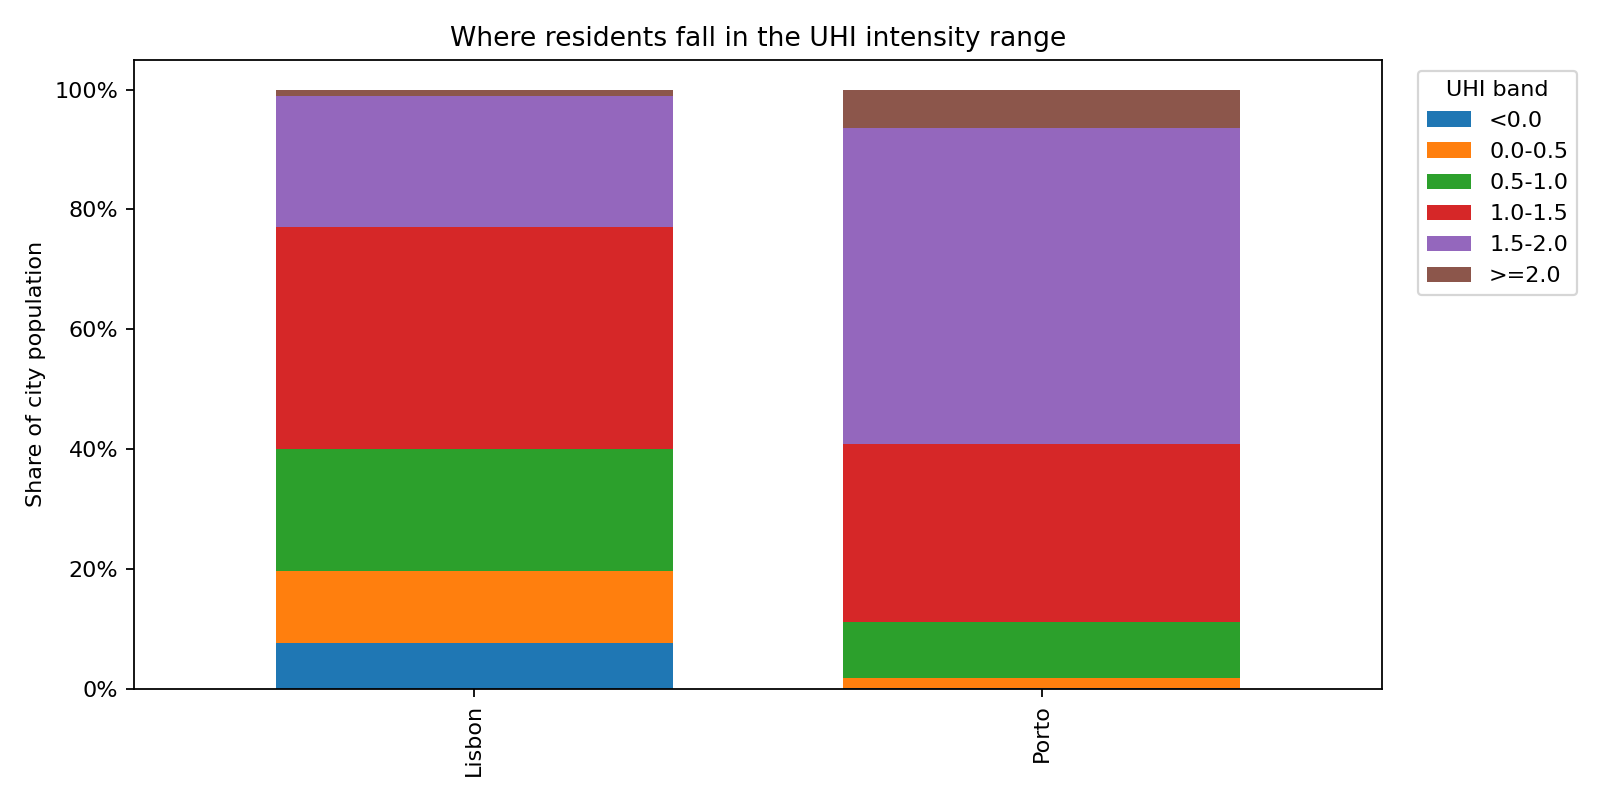

In [8]:
band_plot_path = PLOT_DIR / ("demo_population_uhi_band_comparison.png" if USE_DEMO
                             else "porto_lisbon_population_uhi_band_comparison.png")
plot_population_uhi_band_comparison(cells, band_plot_path)
display(Image(filename=band_plot_path))

## Green space and urban heat: do parks cool the city?

The exposure sections ask *who* lives in hot cells. The more basic question is *why* some
cells are hot at all. The leading explanation is land cover: sealed, built-up centres trap
heat, while parks and vegetation cool their surroundings through shade and evapotranspiration.

We test this directly. For every 1 km cell we measure the **share covered by parks and
vegetation** -- OpenStreetMap parks, gardens, woodland and grass, unioned per city and
intersected with each cell -- and relate that green-cover fraction to the cell's modelled UHI
intensity. (OpenStreetMap green areas are downloaded once via the Overpass API and cached.)

In [9]:
cells = attach_green_fraction(cells, GREEN_CACHE)
green_relationship = compute_green_uhi_relationship(cells)
green_relationship.round(3)

,city,n_cells,mean_green_fraction,weighted_corr_green_uhi,celsius_per_10pp_green
0,Lisbon,711,0.252,-0.396,-0.128
1,Porto,525,0.183,-0.319,-0.087


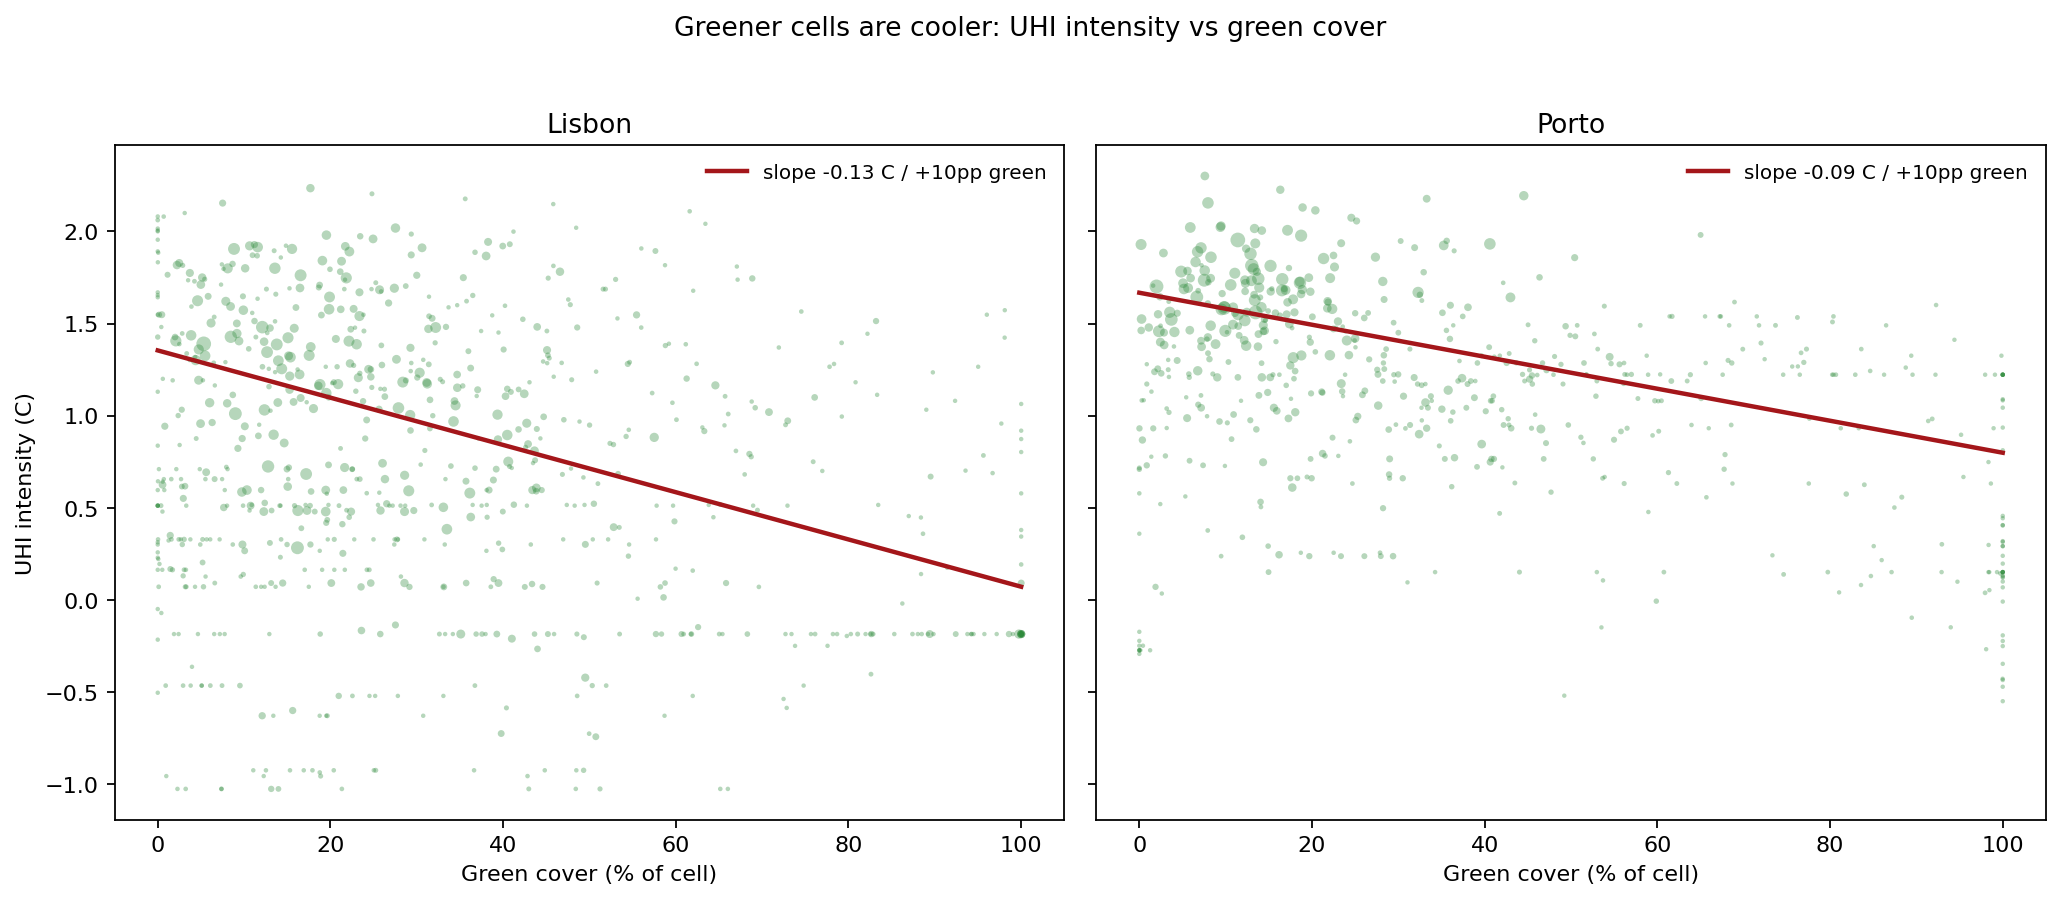

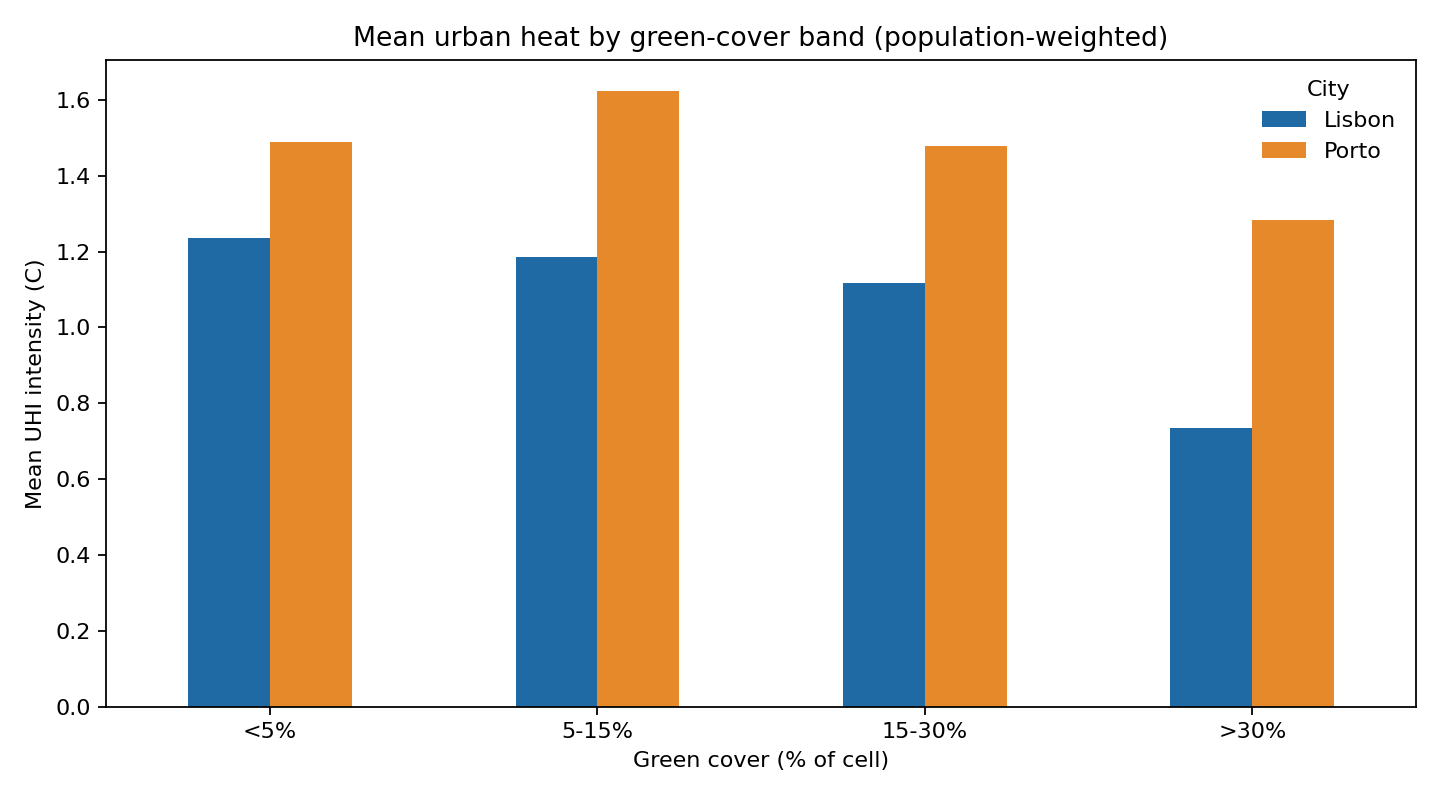

,city,green_band,population,mean_uhi_celsius
0,Lisbon,<5%,141707.723,1.235
1,Lisbon,5-15%,463036.912,1.187
2,Lisbon,15-30%,697424.623,1.117
3,Lisbon,>30%,548830.114,0.736
4,Porto,<5%,103481.660,1.489
5,Porto,5-15%,404257.741,1.625
6,Porto,15-30%,285039.747,1.480
7,Porto,>30%,165579.535,1.283


In [10]:
uhi_by_green_band = compute_uhi_by_green_band(cells)
green_scatter_path = PLOT_DIR / ("demo_green_vs_uhi.png" if USE_DEMO
                                 else "porto_lisbon_green_vs_uhi.png")
green_band_path = PLOT_DIR / ("demo_uhi_by_green_band.png" if USE_DEMO
                              else "porto_lisbon_uhi_by_green_band.png")
plot_green_vs_uhi(cells, green_scatter_path)
plot_uhi_by_green_band(uhi_by_green_band, green_band_path)
display(Image(filename=green_scatter_path))
display(Image(filename=green_band_path))
uhi_by_green_band.round(3)

**Reading this.** Both cities show a clear **negative** relationship — greener cells are
cooler. The population-weighted correlation between green cover and UHI intensity is about
**-0.40 in Lisbon and -0.32 in Porto**, and the regression slope implies roughly **0.13 C of
cooling per +10 percentage points of green cover in Lisbon** (about 0.09 C in Porto). The
banded means say the same thing: Lisbon cells with over 30% green run about **half a degree
cooler** than cells with under 5% green. Built-up cells with little green are the hottest;
well-vegetated cells are the coolest.

This is an **association in modelled data**, not a controlled experiment — green space, building
density and coastal position all move together — but the relationship is consistent across both
cities and in the direction the physics predicts.

## Who is exposed? Population groups in the hottest cells

Green cover explains *where* the heat is. The second question is *who lives there*. For each group we compare its share inside the heat-exposed cells with its share in the city as a whole (a ratio above 1 means the group is concentrated in hotter cells), then test that ratio for significance and check it against a threshold-free dose-response.

In [11]:
representation = compute_group_representation(cells, threshold=UHI_THRESHOLD_CELSIUS)
representation.sort_values(["city", "representation_ratio"], ascending=[True, False])

,city,group,city_group_count,exposed_group_count,city_group_share,exposed_group_share,difference_percentage_points,representation_ratio,is_overrepresented
3,Lisbon,born_outside_eu,2.842576e+05,4794.454585,0.153570,0.245640,9.207067,1.599536,True
2,Lisbon,not_employed,1.049505e+06,11677.865529,0.566994,0.598307,3.131362,1.055227,True
0,Lisbon,children_0_14,2.592130e+05,2860.390920,0.140039,0.146550,0.651063,1.046491,True
1,Lisbon,older_65_plus,4.211565e+05,4052.274713,0.227529,0.207615,-1.991385,0.912478,False
7,Porto,born_outside_eu,6.081594e+04,4453.000000,0.063458,0.072369,0.891042,1.140413,True
5,Porto,older_65_plus,2.161447e+05,15677.000000,0.225536,0.254778,2.924172,1.129654,True
6,Porto,not_employed,5.506193e+05,38353.000000,0.574544,0.623302,4.875764,1.084863,True
4,Porto,children_0_14,1.189934e+05,6832.000000,0.124164,0.111032,-1.313204,0.894236,False


## Is the over-representation statistically meaningful? (bootstrap CIs)

The representation ratios above are point estimates computed on a **small exposed tail**
(roughly 1-6% of each city's population), so a ratio of 1.05 could easily be noise. We
resample cells with replacement within each city (2,000 times) to put a **90% confidence
interval** on every ratio. A finding is only "real" if its interval excludes 1.0.

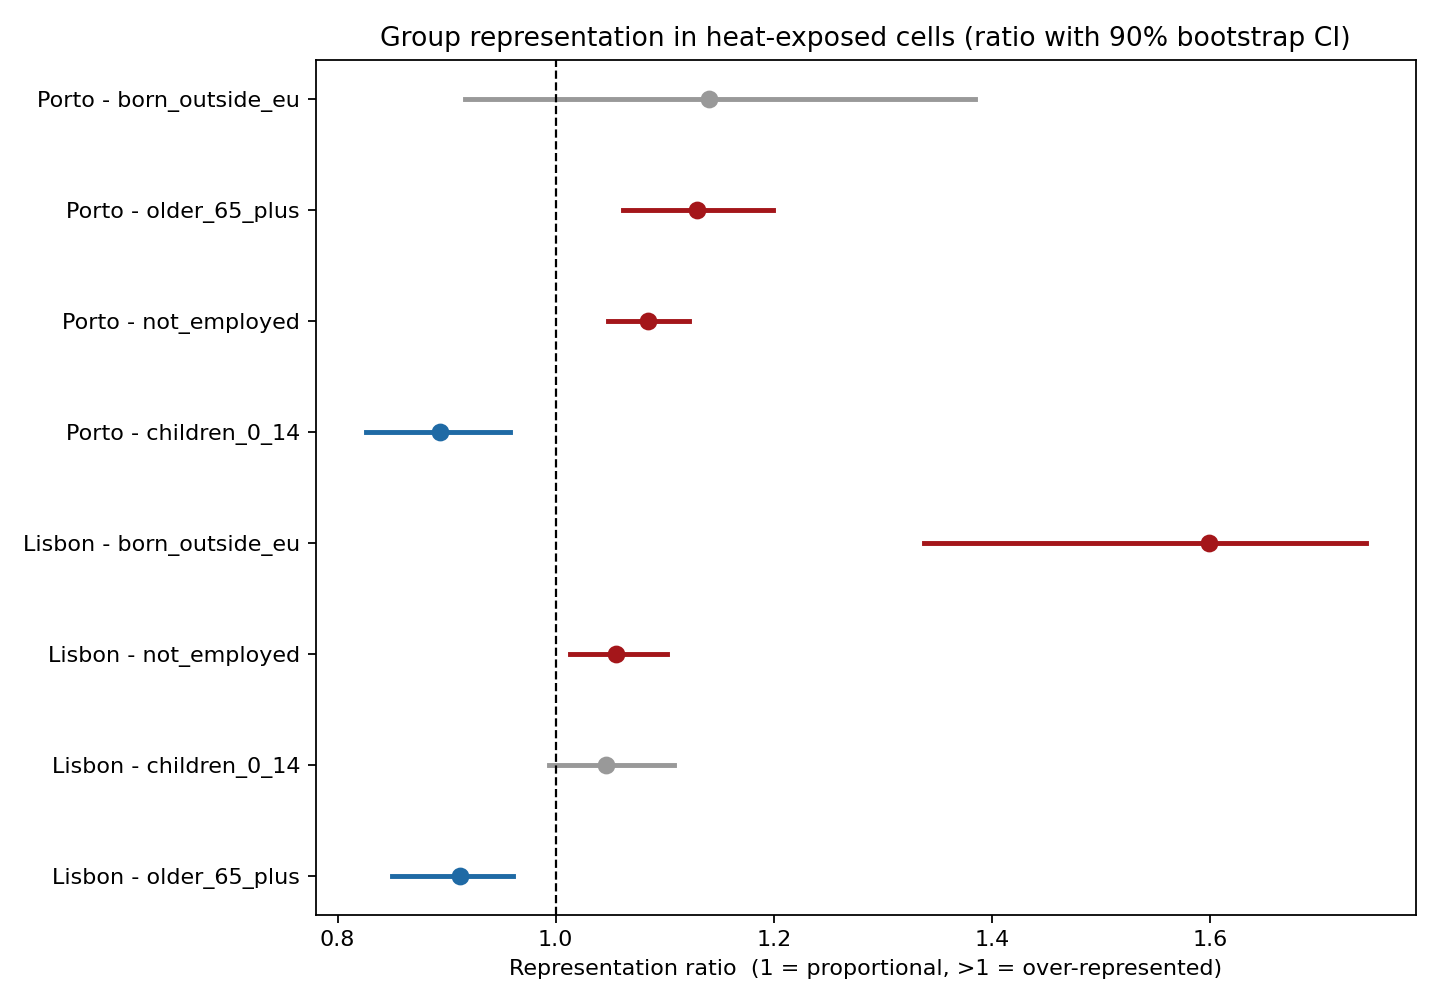

,city,group,representation_ratio,ci_low,ci_high,prob_overrepresented,significant
0,Lisbon,children_0_14,1.046,0.994,1.109,0.936,False
1,Lisbon,older_65_plus,0.912,0.850,0.961,0.010,True
2,Lisbon,not_employed,1.055,1.013,1.102,0.985,True
3,Lisbon,born_outside_eu,1.600,1.338,1.743,0.992,True
4,Porto,children_0_14,0.894,0.826,0.958,0.004,True
5,Porto,older_65_plus,1.130,1.061,1.199,1.000,True
6,Porto,not_employed,1.085,1.048,1.122,1.000,True
7,Porto,born_outside_eu,1.140,0.917,1.384,0.848,False


In [12]:
representation_ci = bootstrap_group_representation(
    cells, threshold=UHI_THRESHOLD_CELSIUS, n_boot=2000, ci=0.90, random_state=42,
)
ci_plot_path = PLOT_DIR / ("demo_representation_ci.png" if USE_DEMO
                           else "porto_lisbon_representation_ci.png")
plot_representation_with_ci(representation_ci, ci_plot_path)
display(Image(filename=ci_plot_path))
representation_ci.round(3)

**Reading this.** `ci_low`/`ci_high` are the 90% bootstrap interval for the representation
ratio; `prob_overrepresented` is the bootstrap probability the ratio exceeds 1; `significant`
is True when the interval is entirely on one side of 1. The picture is more cautious than the
raw ratios: Lisbon's born-outside-EU over-representation (1.6x) is strongly significant, but
Porto's born-outside-EU ratio is **not** distinguishable from proportional, and Lisbon's
children ratio is borderline. (Cells are spatially autocorrelated, so these intervals are
mildly optimistic — treat them as a screen.)

## A threshold-free check: dose-response

A single 2 C threshold is a modelling choice. As an independent check we ignore the threshold
entirely and measure how each group's **local population share** moves with a cell's UHI
intensity across **all** cells (population-weighted correlation and a slope in percentage
points of share per +1 C). A positive value means the group is concentrated in hotter cells.

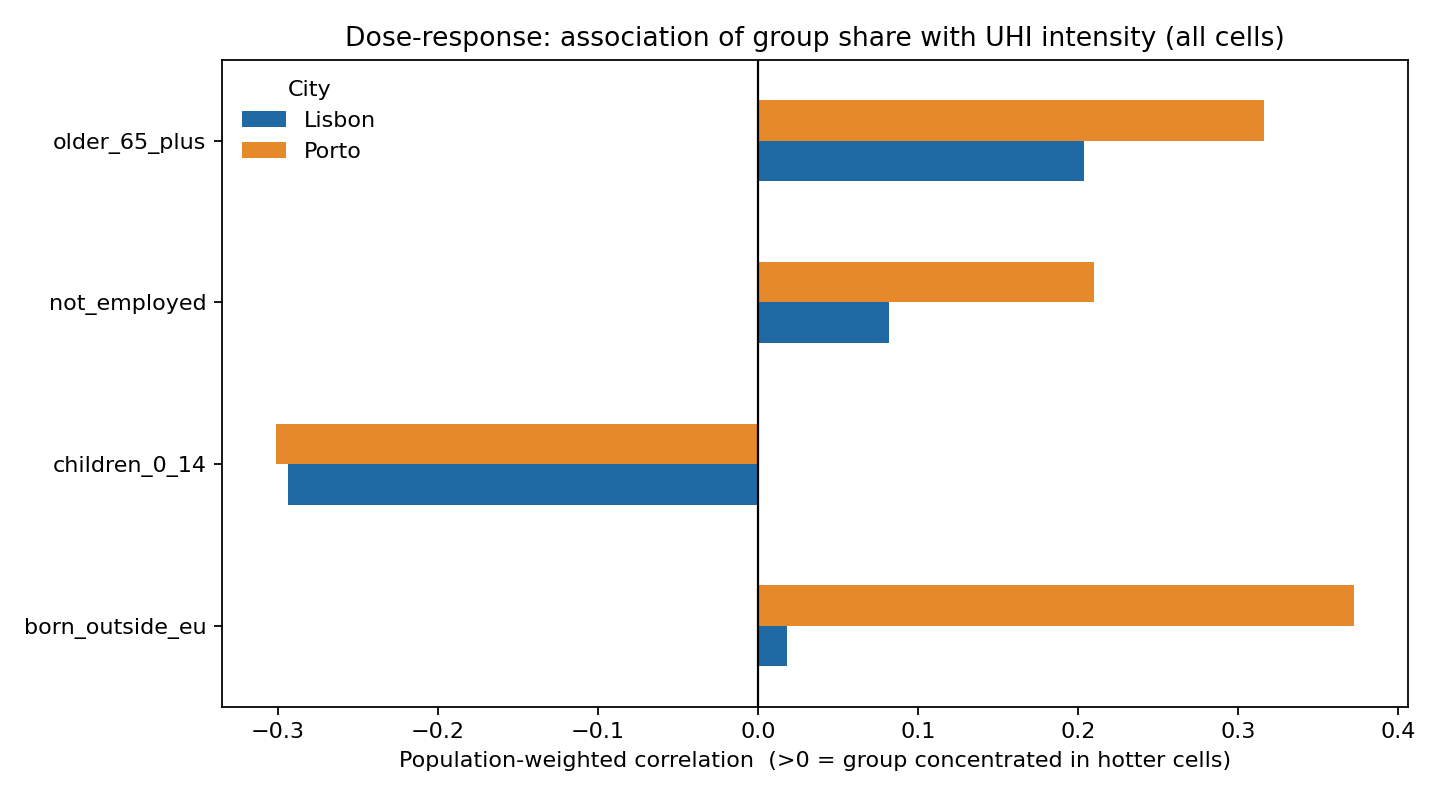

,city,group,weighted_corr_uhi_share,slope_pp_share_per_degree
0,Lisbon,children_0_14,-0.294,-1.272
1,Lisbon,older_65_plus,0.204,1.752
2,Lisbon,not_employed,0.082,0.536
3,Lisbon,born_outside_eu,0.018,0.157
4,Porto,children_0_14,-0.301,-1.653
5,Porto,older_65_plus,0.316,3.763
6,Porto,not_employed,0.210,2.309
7,Porto,born_outside_eu,0.372,3.331


In [13]:
dose_response = compute_dose_response(cells)
dose_plot_path = PLOT_DIR / ("demo_dose_response.png" if USE_DEMO
                             else "porto_lisbon_dose_response.png")
plot_dose_response(dose_response, dose_plot_path)
display(Image(filename=dose_plot_path))
dose_response.round(3)

**Reading this.** The continuous view sometimes **disagrees** with the threshold ratio, and
that is informative. Lisbon's born-outside-EU signal is near-zero on the gradient (correlation
~0.02) despite a high threshold ratio — it is an **extreme-tail** effect, driven by the few
hottest cells, not a city-wide gradient. In Porto, by contrast, older and migrant residents
show a clear positive gradient (correlation ~0.3-0.4) that rises smoothly with heat. Children
are negatively associated with heat in both cities.

## Double burden: where heat and vulnerability coincide

Heat exposure and demographic vulnerability are usually reported separately. Splitting each
city's cells at the population-weighted median of UHI intensity **and** of the heat-vulnerable
age share (children plus over-65s) gives four quadrants. The "high heat + high vulnerability"
quadrant is the **double burden** — heat falling on the residents least able to cope.

In [14]:
double_burden = compute_double_burden(cells)
write_dataframe(
    double_burden,
    OUTPUT_DIR / ("demo_double_burden.csv" if USE_DEMO else "porto_lisbon_double_burden.csv"),
)
double_burden.round(3)

,city,quadrant,population,population_share,mean_uhi_celsius
0,Lisbon,high heat + high vulnerability (double burden),491486.652,0.266,1.526
1,Lisbon,high heat + low vulnerability,435170.650,0.235,1.531
2,Lisbon,low heat + high vulnerability,446831.344,0.241,0.608
3,Lisbon,low heat + low vulnerability,477510.726,0.258,0.461
4,Porto,high heat + high vulnerability (double burden),287826.198,0.300,1.816
5,Porto,high heat + low vulnerability,196794.212,0.205,1.762
6,Porto,low heat + high vulnerability,193685.320,0.202,1.230
7,Porto,low heat + low vulnerability,280052.952,0.292,1.204


**Reading this.** If heat and vulnerability were independent, each quadrant would hold ~25%
of the population. In Porto the double-burden quadrant holds **~30%** — vulnerable residents
are disproportionately in the hotter half of the city. Lisbon is closer to the ~25% null,
consistent with its concern being concentrated in a narrower migrant-heavy tail rather than
spread across the vulnerable-age population.

## Reconstructed spatial view

The prepared CSV does not store geometries, but the Eurostat grid cell ids encode them. This section reconstructs each 1 km square and uses that to create a pseudo-map of the UHI field, with the hottest populated fragments highlighted.


In [15]:
cells_geo = prepared_cells_to_geodataframe(cells)
cells_geo[["city", "cell_id", "uhi_intensity_celsius"]].head()

,city,cell_id,uhi_intensity_celsius
0,Lisbon,CRS3035RES1000mN1929000E2657000,0.140198
1,Lisbon,CRS3035RES1000mN1933000E2674000,1.645599
2,Lisbon,CRS3035RES1000mN1930000E2674000,1.669006
3,Lisbon,CRS3035RES1000mN1929000E2674000,1.477478
4,Lisbon,CRS3035RES1000mN1925000E2668000,1.265320


C:\Users\diogo\work_code\ds-projects-portfolio\projects\porto_lisbon_uhi_exposure\src\uhi_exposure\plotting.py:351: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


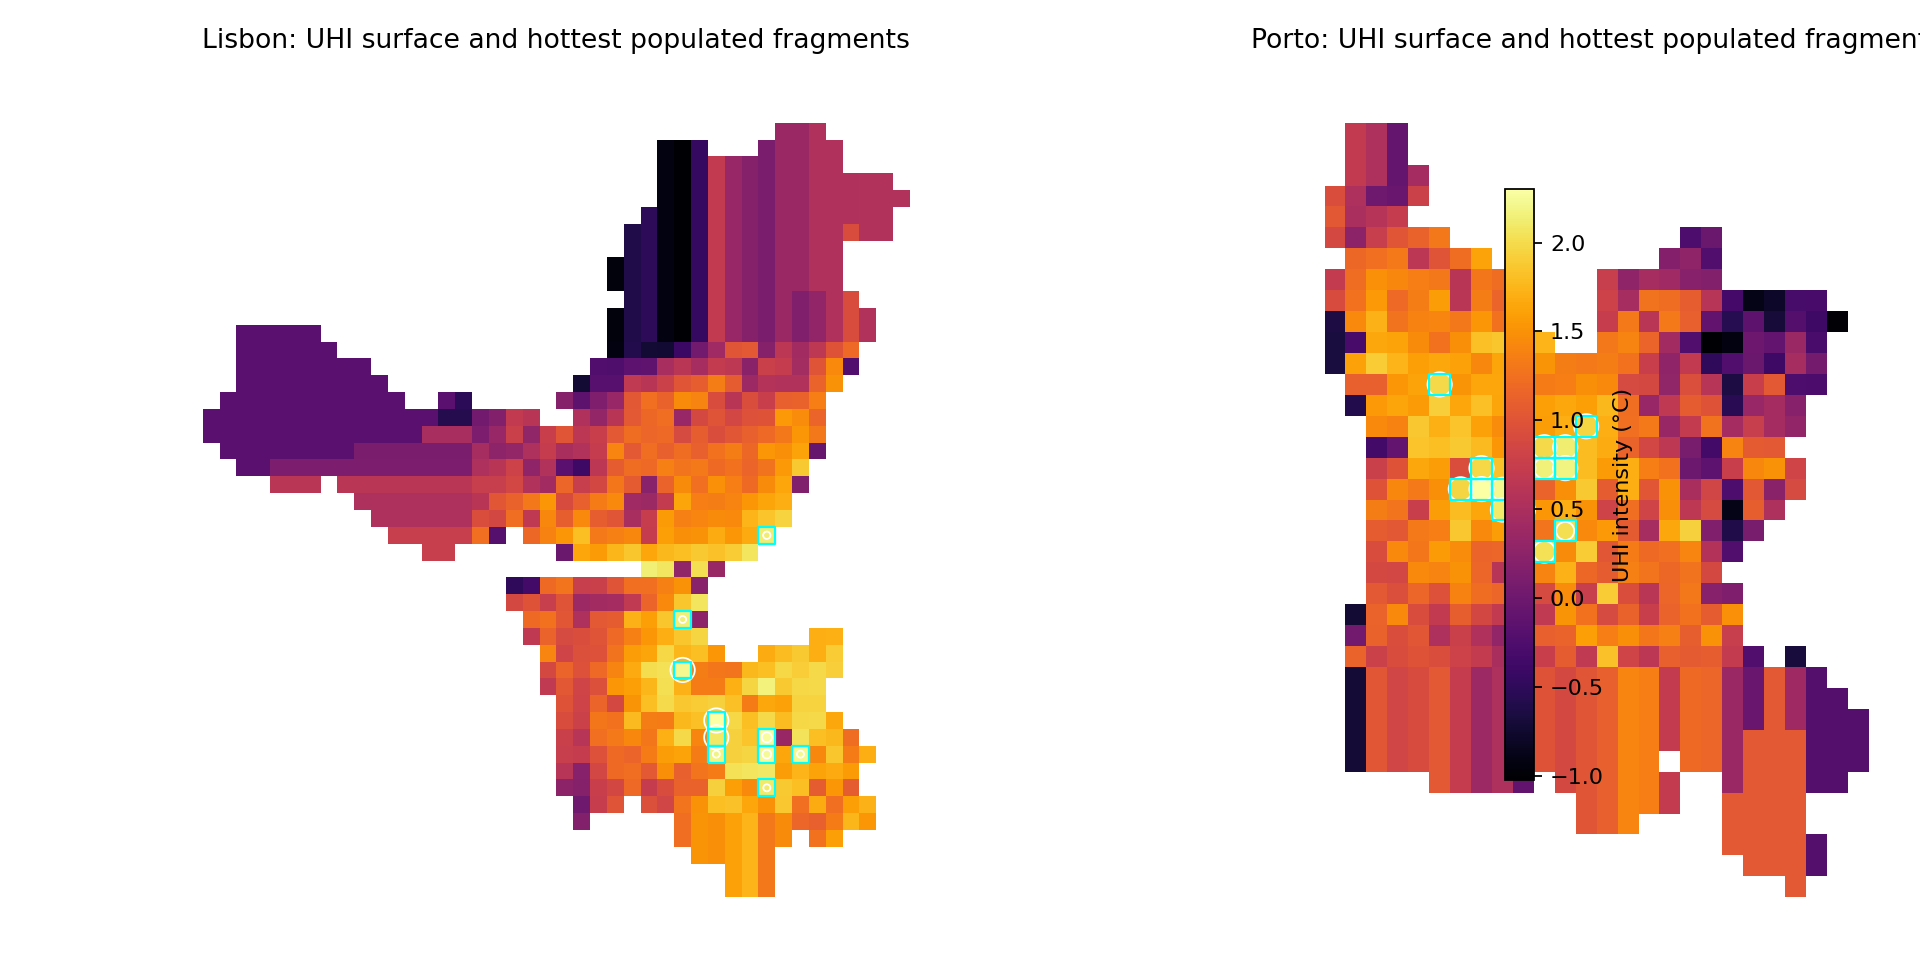

In [16]:
hotspot_path = PLOT_DIR / ("demo_hotspot_map.png" if USE_DEMO
                          else "porto_lisbon_hotspot_map.png")
plot_hotspot_map(cells_geo, hotspot_path)
display(Image(filename=hotspot_path))

## Save outputs

This cell writes the city summary and the group representation table to `outputs/` so the numeric results can be reused outside the notebook.


In [17]:
summary_path = OUTPUT_DIR / ("demo_city_summary.csv" if USE_DEMO else "porto_lisbon_city_summary.csv")
representation_path = OUTPUT_DIR / ("demo_group_representation.csv" if USE_DEMO else "porto_lisbon_group_representation.csv")

write_dataframe(city_summary, summary_path)
write_dataframe(representation, representation_path)

summary_path, representation_path

(WindowsPath('C:/Users/diogo/work_code/ds-projects-portfolio/projects/porto_lisbon_uhi_exposure/outputs/porto_lisbon_city_summary.csv'),
 WindowsPath('C:/Users/diogo/work_code/ds-projects-portfolio/projects/porto_lisbon_uhi_exposure/outputs/porto_lisbon_group_representation.csv'))

## Real-data rebuild notes

The geospatial preparation is implemented in `scripts/prepare_real_data.py`.

Run it when you want to refresh `data/manual/porto_lisbon_cells.csv` from source data instead of reusing the prepared table:

```bash
poetry run python scripts/prepare_real_data.py --output data/manual/porto_lisbon_cells.csv --threshold 2.0
```


## Conclusions

0. **Green space is the clearest driver of where heat lands.** In both cities, cells with more park/vegetation cover are significantly cooler: the population-weighted correlation between green cover and UHI intensity is about -0.40 (Lisbon) and -0.32 (Porto), and the best-vegetated cells run roughly half a degree cooler than the most built-up ones. Built-up centres without parks are the hot spots.

Reading the representation ratios **with their bootstrap confidence intervals** changes which
findings actually survive:

1. **Porto carries the larger and broader heat burden.** A much bigger share of its population
   sits above the 2 C threshold than Lisbon (~6.4% vs ~1.1%), and ~30% of Porto residents fall
   in the high-heat + high-vulnerability double-burden quadrant (vs the 25% a no-association
   null would give).
2. **In Lisbon, residents born outside the EU are significantly over-represented in exposed
   cells (1.6x, 90% CI excludes 1)** — the single strongest signal in the study. In **Porto**
   the same group's threshold ratio is *not* statistically distinguishable from proportional
   (CI includes 1), so the earlier "both cities" reading does **not** hold at the threshold.
3. **Older residents** are significantly over-represented in Porto's hot cells but significantly
   *under*-represented in Lisbon's — the two cities genuinely differ.
4. **The threshold and the continuous dose-response disagree, informatively.** Lisbon's
   born-outside-EU result is an *extreme-tail* effect (flat gradient overall, high ratio in the
   few hottest cells); Porto's elderly and migrant concentration instead rises *smoothly* with
   heat across the whole gradient.
5. **Children are consistently *under*-represented** in the hottest cells in both cities.

One-line summary: **in Lisbon the heat-equity concern is concentrated among residents born
outside the EU and confined to a small hot tail; in Porto it is broader (older and non-employed
residents), rises with heat across the city, and touches a far larger share of the population.**
These conclusions hold for the Urban Audit city polygons and the published UrbClim service, not
the municipalities people informally mean by "Lisbon" and "Porto".

## Caveats

- The threshold is a modelling decision, not a natural law.
- The output inherits the strengths and limits of the Eurostat grid and the published UrbClim service.
- Area-weighted fragments create fractional counts by construction.
- Results can differ sharply from municipality-based expectations because the Urban Audit city polygons are larger than municipal boundaries.
- Confidence intervals come from a cell-level bootstrap; neighbouring cells are spatially correlated, so the true intervals are somewhat wider than reported.